# Data Visualization: A Notebook for visualizing gym IMU Data


In [507]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.signal import butter, filtfilt
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
#

# Suppress minor warnings
import warnings
warnings.filterwarnings('ignore')

In [508]:
print(np.__version__)

1.26.4


In [509]:
#ip install "numpy<2"

In [510]:
#import umap.umap_ as umap

In [511]:
DATASETS = "ALL" # "ONLINE", "OURS", "ALL", "ALL_PARENT_ONLY"

In [512]:
df = pd.read_csv('golden_dataset_v9.csv')

In [513]:
df['dataset'].unique()

array(['ourdata', 'myogym', 'lean'], dtype=object)

In [514]:
#df_golden_ours = df[df['dataset'] == 'ourdata']

In [515]:
#df_golden_ours['child'].unique()

In [516]:
df_ours = pd.read_csv('OurData_v5.csv')

In [517]:
df_ours['child'].unique()

array([10,  2,  1,  7,  9,  5,  8,  4,  6,  3])

In [518]:
df_ours.insert(11,'dataset', 'ours')

In [519]:
df_ours.columns

Index(['x_accel', 'y_accel', 'z_accel', 'x_gyro', 'y_gyro', 'z_gyro', 'parent',
       'child', 'participant', 'set', 'ID', 'dataset'],
      dtype='object')

In [520]:
print(df['child'].unique())
print(df_ours['child'].unique())

[5 3]
[10  2  1  7  9  5  8  4  6  3]


In [521]:
df['participant'].unique()
print(df_ours['participant'].unique())

[18 15 19 17 16]


In [522]:
df_ours['participant'].dropna( inplace=True)

In [523]:
# subject_mapping = {
#     21:23,
#     22:24,
#     23:25,
#     24:26,
#     25:27
# }

In [524]:

#df_ours['participant'] = df_ours['participant'].map(subject_mapping)


In [525]:
df_ours['participant'].unique()

array([18, 15, 19, 17, 16])

In [526]:
df_ours

,x_accel,y_accel,z_accel,x_gyro,y_gyro,z_gyro,parent,child,participant,set,ID,dataset
0,0.068971,0.034946,0.068123,-6.839884,-69.760855,-71.674865,5,10,18,1,97,ours
1,0.108145,0.076554,0.066800,-5.538772,-70.361505,-83.996725,5,10,18,1,97,ours
2,0.060400,0.003970,-0.124604,3.534447,-68.971041,-90.763912,5,10,18,1,97,ours
3,0.004598,0.018236,-0.127386,20.759711,-57.055608,-90.620436,5,10,18,1,97,ours
4,0.046318,0.007348,-0.067597,40.492570,-57.693020,-85.808185,5,10,18,1,97,ours
...,...,...,...,...,...,...,...,...,...,...,...,...
52823,-0.168265,-0.005138,-0.152343,-8.948471,16.928100,-1.029411,1,4,15,1,31,ours
52824,-0.082134,0.057244,-0.375063,-5.153496,1.721762,-11.209027,1,4,15,1,31,ours
52825,0.049525,0.064899,-0.357656,-2.470827,-22.219207,-24.236341,1,4,15,1,31,ours
52826,0.140999,0.141055,-0.374266,6.870881,-43.495998,-37.749526,1,4,15,1,31,ours


In [527]:
df['child'].unique()

array([5, 3])

In [528]:
new_df = pd.concat([df, df_ours], ignore_index=True)

In [529]:
new_df['parent'].unique()

array([5, 1])

In [530]:
if DATASETS == "ONLINE":
    df = df
elif DATASETS == "OURS":
    df = df_ours
elif DATASETS == "ALL":
    df = new_df
elif DATASETS == "ALL_PARENT_ONLY":
    df = new_df[(new_df['child'] == 3) | (new_df['child'] == 5)]
elif DATASETS == "OURS_ARMCURL":
    df = df_ours[(df_ours['child'] == 1) | (df_ours['child'] == 2) | (df_ours['child'] == 3)|(df_ours['child'] == 4)]
elif DATASETS == "OURS_PARENT_ONLY":
    df = df_ours[(df_ours['child'] == 3) | (df_ours['child'] == 5)]

In [531]:
df['child']

0        5
1        5
2        5
3        5
4        5
        ..
78037    4
78038    4
78039    4
78040    4
78041    4
Name: child, Length: 78042, dtype: int64

In [532]:
#df = df[(df['child'] == 3) | (df['child'] == 5)]

In [533]:
df.shape

(78042, 12)

## Prepare our data

In [534]:
# ============================================================
# LABEL MAPS
#   Class 0  =  rest / background  →  removed after windowing
#   Class 1+ =  valid exercise classes (kept)
# Add or remove entries freely; the rest of the notebook adapts
# automatically to however many classes remain after filtering.
# ============================================================
# label_map_parent = {
#     (1,1): 0,
#     (5,5): 2, 
#     (1,2): 0,
#     (1,3): 1,
#     (1,4): 0,
#     (5,6): 0,
#     (5,7): 0,
#     (5,8): 0,
#     (5,9): 0,
#     (5,10): 0,
# }
label_map_parent = {0:0,
                   1:3,
                   2:3,
                   3:3,
                   4:3,
                   5:5,
                   6:5,
                   7:5,
                   8:5,
                   9:5,
                   10:5}
label_map_child = {0:0,
                   1:1,
                   2:2,
                   3:3,
                   4:4,
                   5:5,
                   6:6,
                   7:7,
                   8:8,
                   9:9,
                   10:10}

# Optional human-readable names for each class label (used in plot legends).
# Any label not listed here will fall back to "Class <N>".
CLASS_NAMES_PARENT = {
    1: "Arm Curl",
    2: "Bench Press",
}
CLASS_NAMES_CHILD = {
    1: "Alternating Dumbell Curl",
    2: "Preacher Curls",
    3: "Arm Curls (PARENT)",
    4: "Reverse Barbell Curls",
    5: "Bench Press (PARENT)",
    6: "Incline Barbell Bench Press",
    7: "Decline  Barbell Bench Press",
    8: "Flat Dumbbell Bench Press",
    9: "Incline Dumbbell Bench Press",
    10: "Decline  Dumbbell Bench Press"

}

DATASET_NAMES = {
    'm': 'MyoGym',
    'g': 'Gym Workout',
    'l': 'Lean',
    'o': 'Ours'

}

IMU_COLS        = ["x_accel", "y_accel", "z_accel", "x_gyro", "y_gyro", "z_gyro"]
LABEL_COL       = "exercise"
PARTICIPANT_COL = "participant"
DATASET_COL     = "dataset"   
VIEW            = "child"   # 'parent' or 'child'

In [535]:
df['participant'] = df['participant'].astype(int)

# Select the active label map based on VIEW
if VIEW == 'parent':
    active_label_map = label_map_parent
else:
    active_label_map = label_map_child

df['child'] = df['child'].map(active_label_map)
# Drop rows whose original label wasn't in the map (NaN after mapping)
df = df.dropna(subset=[VIEW])
df['child'] = df['child'].astype(int)
df = df.dropna(subset=IMU_COLS).reset_index(drop=True)
print(df['child'].unique())
print(f"Unique mapped labels (including background 0): {sorted(df[VIEW].unique())}")

# Build per-subject dict: {subject_id -> (imu_array [T,C], labels [T,])}
subjects     = sorted(df[PARTICIPANT_COL].unique())
subject_data = {}
for subj in subjects:
    mask = df[PARTICIPANT_COL] == subj
    imu  = df.loc[mask, IMU_COLS].values.astype(np.float64)
    labs = df.loc[mask, 'child'].values.astype(np.int64)
    dataset = df.loc[mask, DATASET_COL].values[0]  # Assuming one dataset per subject
    subject_data[subj] = (imu, labs, dataset)

print(f"\nLoaded {len(subjects)} subjects: {subjects}")
for s, (imu, labs, dataset) in subject_data.items():
    print(f"  Subject {s:>4}: {imu.shape[0]:>6} samples  "
          f"classes (pre-windowing)={np.unique(labs).tolist()}")

[ 5  3 10  2  1  7  9  8  4  6]
Unique mapped labels (including background 0): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Loaded 19 subjects: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
  Subject    1:    673 samples  classes (pre-windowing)=[5]
  Subject    2:    745 samples  classes (pre-windowing)=[5]
  Subject    3:    401 samples  classes (pre-windowing)=[5]
  Subject    4:    255 samples  classes (pre-windowing)=[5]
  Subject    5:    629 samples  classes (pre-windowing)=[5]
  Subject    6:    457 samples  classes (pre-windowing)=[5]
  Subject    7:    438 samples  classes (pre-windowing)=[5]
  Subject    8:    429 samples  classes (pre-windowing)=[5]
  Subject    9:    680 samples  classes (pre-windowing)=[5]
  Subject   10:    522 samples  classes (pre-windowing)=[5]
  Subject   11:   7752 samples  classes (pre-windowing)=[3]
  Subject   12:    690 samples  classes (pre-windowing)=[3]
  Subject   13:   1110 samples  classes (pre-windowing)=[3]
  Subject   14:    5

## Initialize Variables and Data Processing Objects

In [536]:
# ============================================================
# CONFIGURATION — edit these to match your setup
# ============================================================
SAMPLING_RATE    = 20     # Hz — your IMU's sampling frequency
NUM_IMU_CHANNELS = 6      # 6 = accel+gyro, 3 = accel only, 9 = +magnetometer
WINDOW_SIZE_SEC  = 4.0    # seconds per window
OVERLAP          = 0.5    # fractional overlap between consecutive windows (0.0–<1.0)
EPOCHS           = 50     # max training epochs
BATCH_SIZE       = 32
N_FOLDS          = 5      # used only in the optional comparison section
LEARNING_RATE    = 1e-3
PATIENCE         = 100    # early stopping patience

In [537]:
class IMUPreprocessor:
    """
    Preprocessing pipeline for IMU-only data.

    Steps:
      1. Denoising    — 6th-order zero-phase Butterworth bandpass (1–20 Hz)
      2. Normalize    — Per-channel min–max scaling to [0, 1]
      3. Segment      — Sliding window with overlap + majority-vote labels
      4. Filter       — Remove windows whose majority label == 0 (background/rest)
      5. Features     — Per-channel statistical feature extraction per window

    Multiclass-robust: works for any number of non-zero classes.
    """

    # Features extracted per channel
    FEATURE_NAMES_PER_CHANNEL = [
        "mean", "median", "std", "var",
        "iqr", "skew", "kurtosis",
        "min", "max", "range", "rms"
    ]

    def __init__(self, sampling_rate=20, window_size_sec=2.0, overlap=0.5,
                 imu_lowcut=1.0, imu_highcut=20.0, filter_order=6):
        self.fs           = sampling_rate
        self.window_size  = int(window_size_sec * sampling_rate)
        # Clamp step_size to at least 1 regardless of overlap value
        self.step_size    = max(1, int(self.window_size * (1.0 - overlap)))
        self.lowcut       = imu_lowcut
        self.highcut      = imu_highcut
        self.filter_order = filter_order

    # ----- 3.3.1 Denoising -----
    def denoise(self, data: np.ndarray) -> np.ndarray:
        """6th-order zero-phase Butterworth bandpass, per channel."""
        nyq = 0.5 * self.fs
        lo  = self.lowcut  / nyq
        hi  = min(self.highcut / nyq, 0.99)
        if lo <= 0 or lo >= hi:
            return data.copy()
        b, a    = butter(self.filter_order, [lo, hi], btype="band")
        out     = np.zeros_like(data, dtype=np.float64)
        min_len = 3 * max(len(b), len(a))
        for ch in range(data.shape[1]):
            if data.shape[0] > min_len:
                out[:, ch] = filtfilt(b, a, data[:, ch])
            else:
                out[:, ch] = data[:, ch]
        return out

    # ----- 3.3.2 Normalization -----
    def fit_normalize(self, data: np.ndarray) -> np.ndarray:
        """Fit per-channel min/max on this data, return normalized copy."""
        self._min = data.min(axis=0)
        self._max = data.max(axis=0)
        return self._apply_norm(data)

    def transform_normalize(self, data: np.ndarray) -> np.ndarray:
        """Apply previously fitted min-max (for test/inference)."""
        return np.clip(self._apply_norm(data), 0.0, 1.0)

    def _apply_norm(self, data: np.ndarray) -> np.ndarray:
        denom          = self._max - self._min
        denom[denom == 0] = 1.0
        return ((data - self._min) / denom).astype(np.float32)

    # ----- 3.3.3 Sliding-window segmentation -----
    def segment(self, data: np.ndarray, labels: np.ndarray):
        """Sliding window with majority-vote labeling."""
        X, y = [], []
        T    = data.shape[0]
        for s in range(0, T - self.window_size + 1, self.step_size):
            window  = data[s : s + self.window_size]
            wlabels = labels[s : s + self.window_size]
            if len(wlabels) == 0:
                continue
            vals, cnts    = np.unique(wlabels, return_counts=True)
            majority_label = vals[cnts.argmax()]
            X.append(window)
            y.append(majority_label)
        return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

    # ----- 3.3.4 Feature extraction -----
    def extract_features(self, windows: np.ndarray) -> np.ndarray:
        """
        Extract per-channel statistical features from segmented windows.

        Parameters
        ----------
        windows : np.ndarray, shape (N, T, C)

        Returns
        -------
        features : np.ndarray, shape (N, C * len(FEATURE_NAMES_PER_CHANNEL) + n_sma_groups)
        """
        N, T, C      = windows.shape
        all_features = []

        for window in windows:
            ch_features = []

            for ch in range(C):
                sig = window[:, ch].astype(np.float64)

                mean_val   = np.mean(sig)
                median_val = np.median(sig)
                std_val    = np.std(sig, ddof=1) if T > 1 else 0.0
                var_val    = np.var(sig, ddof=1) if T > 1 else 0.0
                iqr_val    = float(np.percentile(sig, 75) - np.percentile(sig, 25))
                skew_val   = float(skew(sig))
                kurt_val   = float(kurtosis(sig))   # excess kurtosis
                min_val    = np.min(sig)
                max_val    = np.max(sig)
                range_val  = max_val - min_val
                rms_val    = np.sqrt(np.mean(sig ** 2))

                ch_features.extend([
                    mean_val, median_val, std_val, var_val,
                    iqr_val, skew_val, kurt_val,
                    min_val, max_val, range_val, rms_val,
                ])

            # Cross-channel: Signal Magnitude Area per axis triplet
            for start in range(0, C - 2, 3):
                sma = np.sum(np.abs(window[:, start:start + 3])) / T
                ch_features.append(float(sma))

            all_features.append(ch_features)

        return np.array(all_features, dtype=np.float32)

    def feature_names(self, n_channels: int) -> list:
        """Return ordered feature names matching extract_features output."""
        names = [
            f"ch{c}_{feat}"
            for c in range(n_channels)
            for feat in self.FEATURE_NAMES_PER_CHANNEL
        ]
        for start in range(0, n_channels - 2, 3):
            names.append(f"sma_axes{start}-{start+2}")
        return names

    # ----- Full pipeline -----
    def preprocess(self, imu_data: np.ndarray, labels: np.ndarray):
        """
        Denoise → normalize → segment → remove class-0 windows → extract features.

        Windows whose majority-vote label == 0 (background/rest) are discarded
        before feature extraction so they never appear in any downstream analysis.
        """
        #denoised   = self.denoise(imu_data)
        #normalized = self.fit_normalize(denoised)
        windows, y = self.segment(imu_data, labels)   # (N, T, C)

        # --- Remove background/rest windows (label == 0) ---
        keep    = y != 0
        windows = windows[keep]
        y       = y[keep]

        if len(y) == 0:
            raise ValueError("No windows remain after removing class-0 windows. "
                             "Check your label map.")

        X = self.extract_features(windows)              # (N, num_features)
        print(f"  Feature matrix: {X.shape}, Labels: {y.shape}, "
              f"classes={np.unique(y).tolist()}")
        return X, y

In [538]:
for subj, (imu_s, labs_s, datasets_s) in subject_data.items():
    print(subj, datasets_s)

1 myogym
2 myogym
3 myogym
4 myogym
5 myogym
6 myogym
7 myogym
8 myogym
9 myogym
10 myogym
11 lean
12 lean
13 lean
14 lean
15 ourdata
16 ourdata
17 ourdata
18 ourdata
19 ourdata


## Rep-Level Visualization

In [539]:
from scipy.signal import find_peaks

import numpy as np
import matplotlib.pyplot as plt


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


def plot_imu_data(
    data: np.ndarray,
    y: np.ndarray = None,
    sample_rate: float = None,
    title: str = "IMU Data",
    activity_names: dict = None,
):
    """
    Plot acceleration and gyroscope data from an IMU with optional activity labels.

    Args:
        data: Array of shape (N, 6) where columns are [ax, ay, az, gx, gy, gz].
        y: Array of shape (N,) with activity labels (0 or 1).
        sample_rate: Sample rate in Hz. If provided, x-axis shows time in seconds.
        title: Overall figure title.
        activity_names: Dict mapping label to name, e.g. {0: "Walking", 1: "Running"}.
    """
    if activity_names is None:
        activity_names = {0: "Null", 1: "Arm Curl", 5: "Bench Press"}

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    n_samples = data.shape[0]
    x = np.arange(n_samples) / sample_rate if sample_rate else np.arange(n_samples)
    x_label = "Time (s)" if sample_rate else "Sample"

    # Shade activity regions
    colors = {0: "#3b82f6", 1: "#f97316", 5: "#10b981"}
    if y is not None:
        for ax in (ax1, ax2):
            _shade_activities(ax, x, y, colors)

    # Accelerometer
    for i, axis in enumerate(["X", "Y", "Z"]):
        ax1.plot(x, data[:, i], label=axis)
    ax1.set_ylabel("Acceleration (m/s²)")
    ax1.set_title("Accelerometer")
    ax1.legend(loc="upper left")
    ax1.grid(True, alpha=0.3)

    # Gyroscope
    for i, axis in enumerate(["X", "Y", "Z"]):
        ax2.plot(x, data[:, i + 3], label=axis)
    ax2.set_ylabel("Angular velocity (°/s)")
    ax2.set_xlabel(x_label)
    ax2.set_title("Gyroscope")
    ax2.legend(loc="upper left")
    ax2.grid(True, alpha=0.3)

    # Activity legend
    if y is not None:
        activity_patches = [
            Patch(facecolor=colors[k], alpha=0.2, label=activity_names[k])
            for k in sorted(colors)
        ]
        fig.legend(
            handles=activity_patches,
            loc="upper right",
            title="Activity",
            framealpha=0.9,
        )

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def _shade_activities(ax, x, y, colors):
    """Shade contiguous regions of the same activity label."""
    changes = np.diff(y)
    boundaries = np.where(changes != 0)[0] + 1
    segments = np.split(np.arange(len(y)), boundaries)

    for seg in segments:
        label = y[seg[0]]
        ax.axvspan(x[seg[0]], x[seg[-1]], alpha=0.15, color=colors[label])

In [540]:
# graph_data = subject_data[16][0]  # Get IMU data for subject 1
# graph_data_y = subject_data[16][1]  # 
# plot_imu_data(graph_data, graph_data_y, title="Subject 1 IMU Data")

In [541]:
#subject_data[17][0][1]# Get IMU data for subject 17

In [542]:
# graph_data_ = subject_data[1][0]  # Get IMU data for subject 1
# plot_imu_data(graph_data, title="Subject 1 IMU Data")

## Process all subjects — build pooled feature matrix

In [543]:
# Run the full preprocessing pipeline on every subject and pool results.
# A separate IMUPreprocessor is instantiated per subject so that
# min-max normalisation is fitted on that subject's data only.

all_X      = []   # feature matrices, one per subject
all_y      = []   # label vectors,    one per subject
all_subj   = []   # subject-id vector (same length as all_y)
all_datasets = [] # dataset-id vector (same length as all_y)

for subj, (imu_s, labs_s, datasets_s) in subject_data.items():
    print(f"Processing subject {subj} …")
    pp = IMUPreprocessor(
        sampling_rate   = SAMPLING_RATE,
        window_size_sec = WINDOW_SIZE_SEC,
        overlap         = OVERLAP,
    )
    X_s, y_s = pp.preprocess(imu_s, labs_s)
    all_X.append(X_s)
    all_y.append(y_s)
    all_subj.append(np.full(len(y_s), subj, dtype=int))
    all_datasets.append(np.full(len(y_s), datasets_s, dtype=str))
X_all    = np.concatenate(all_X,    axis=0)   # (N_total, n_features)
y_all    = np.concatenate(all_y,    axis=0)   # (N_total,)
subj_all = np.concatenate(all_subj, axis=0)   # (N_total,)
datasets_all = np.concatenate(all_datasets, axis=0)   # (N_total,)

unique_classes = sorted(np.unique(y_all).tolist())
print(f"\nPooled dataset: {X_all.shape[0]} windows, "
      f"{X_all.shape[1]} features, classes={unique_classes}")

Processing subject 1 …
  Feature matrix: (15, 68), Labels: (15,), classes=[5]
Processing subject 2 …
  Feature matrix: (17, 68), Labels: (17,), classes=[5]
Processing subject 3 …
  Feature matrix: (9, 68), Labels: (9,), classes=[5]
Processing subject 4 …
  Feature matrix: (5, 68), Labels: (5,), classes=[5]
Processing subject 5 …
  Feature matrix: (14, 68), Labels: (14,), classes=[5]
Processing subject 6 …
  Feature matrix: (10, 68), Labels: (10,), classes=[5]
Processing subject 7 …
  Feature matrix: (9, 68), Labels: (9,), classes=[5]
Processing subject 8 …
  Feature matrix: (9, 68), Labels: (9,), classes=[5]
Processing subject 9 …
  Feature matrix: (16, 68), Labels: (16,), classes=[5]
Processing subject 10 …
  Feature matrix: (12, 68), Labels: (12,), classes=[5]
Processing subject 11 …
  Feature matrix: (192, 68), Labels: (192,), classes=[3]
Processing subject 12 …
  Feature matrix: (16, 68), Labels: (16,), classes=[3]
Processing subject 13 …
  Feature matrix: (26, 68), Labels: (26,), 

In [544]:
type(datasets_all)

numpy.ndarray

In [545]:
subj_all[subj_all == 21].shape

(0,)

In [546]:
# ---- Standardise features before dimensionality reduction ----
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_all)
print(f"Scaled feature matrix: {X_scaled.shape}")

# X_scaled = np.zeros_like(X_all)
# global_std = X_all.std(axis=0)
# global_std[global_std == 0] = 1.0

# for subj in np.unique(subj_all):
#     mask = subj_all == subj
#     subj_mean = X_all[mask].mean(axis=0)
#     X_scaled[mask] = (X_all[mask] - subj_mean) / global_std

Scaled feature matrix: (1922, 68)


In [547]:
X_scaled.shape

(1922, 68)

## Visualization Helpers

In [567]:
def get_class_palette(classes, cmap_name='tab10'):
    """
    Return a dict {class_label: colour} that works for any number of classes.
    Uses tab10 for ≤10 classes, tab20 for ≤20, and hsv beyond that.
    """
    n = len(classes)
    if n <= 10:
        cmap = cm.get_cmap('tab10', n)
    elif n <= 20:
        cmap = cm.get_cmap('tab20', n)
    else:
        cmap = cm.get_cmap('hsv', n)
    return {cls: cmap(i) for i, cls in enumerate(classes)}
NUMBER_NAMES_CHILD = {1:"Child 1",
                      2:"Child 2",
                      3:"Child 3",
                      4:"Child 4",
                      5:"Child 5",
                      6:"Child 6",
                      7:"Child 7",
                      8:"Child 8",
                      9:"Child 9",
                      10:"Child 10"
                      }

def class_label(c):
    """Human-readable class name, falling back to 'Class <N>'."""
    print(NUMBER_NAMES_CHILD.get(c, f"Class {c}"))
    return NUMBER_NAMES_CHILD.get(c, f"Class {c}")

def subject_label(s):
    """Human-readable subject name."""
    return f"Subject {s}"

def dataset_label(s):
    """Human-readable subject name."""
    return DATASET_NAMES.get(s, f"Dataset {s}")

LABEL_COLORS = {
    # Group 1 (blues/teals) — keys 1–4
    1:  '#1a5276',  # dark blue
    2:  '#2980b9',  # medium blue
    3:  '#5dade2',  # light blue
    4:  '#76d7c4',  # teal
    
    # 1: "#E63946",
    # 2: "#457B9D",
    # 3: "#2A9D8F",
    # 4: "#E9C46A",


    # Group 2 (reds/oranges) — keys 5–10
    5:  '#922b21',  # dark red
    6:  '#cb4335',  # red
    7:  '#e74c3c',  # bright red
    8:  '#f39c12',  # amber
    9:  '#e67e22',  # orange
    10: '#f5b041',  # light orange
}
import colorcet as cc
import seaborn as sns
from matplotlib.colors import ListedColormap
def scatter2d_ex(ax, embedding, labels, palette, title, xlabel='Dim 1', ylabel='Dim 2',
              alpha=0.55, s=12):
    """
    Generic 2-D scatter coloured by class. Works for any number of classes.
    """
    for cls in sorted(np.unique(labels)):
        mask = labels == cls
        #print(class_label(cls))
        palette = cc.glasbey[:10]
        custom_cmap = ListedColormap(palette)
        colors = sns.color_palette('husl', 10) 
        ax.scatter(
            embedding[mask, 0], embedding[mask, 1],
             label=class_label(cls),color = LABEL_COLORS[cls],
            alpha=alpha, s=s, linewidths=0
        )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(markerscale=2,
    fontsize=9,
    framealpha=0.7,
       # place it just outside the right edge
    loc='lower right',
    borderaxespad=0)
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)

def scatter2d_sub(ax, embedding, labels, palette, title, xlabel='Dim 1', ylabel='Dim 2',
              alpha=0.55, s=12):
    """
    Generic 2-D scatter coloured by class. Works for any number of classes.
    """
    LABEL_COLORS_5 = {
    15: '#e6194b',  # red
    16: '#3cb44b',  # green
    17: '#4363d8',  # blue
    18: '#f58231',  # orange
    19: '#911eb4',  # purple
}
    for cls in sorted(np.unique(labels)):
        mask = labels == cls
        print(class_label(cls))
        ax.scatter(
            embedding[mask, 0], embedding[mask, 1],
             label=subject_label(cls),
            alpha=alpha, s=s, linewidths=0
        )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(markerscale=2,
    fontsize=9,
    framealpha=0.7,
    bbox_to_anchor=(1.01, 1),   # place it just outside the right edge
    loc='upper left',
    borderaxespad=0)
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)

def scatter2d_dataset(ax, embedding, labels, palette, title, xlabel='Dim 1', ylabel='Dim 2',
              alpha=0.55, s=12):
    """
    Generic 2-D scatter coloured by class. Works for any number of classes.
    """
    for cls in sorted(np.unique(labels)):
        mask = labels == cls
        print(class_label(cls))
        ax.scatter(
            embedding[mask, 0], embedding[mask, 1],
             label=dataset_label(cls),cmap = 'viridis',
            alpha=alpha, s=s, linewidths=0
        )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(markerscale=2,
    fontsize=9,
    framealpha=0.7,
    bbox_to_anchor=(1.01, 1),   # place it just outside the right edge
    loc='upper left',
    borderaxespad=0)
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)

palette = get_class_palette(unique_classes)
print("Class palette:", {class_label(c): palette[c] for c in unique_classes})



Child 1
Child 2
Child 3
Child 4
Child 5
Child 6
Child 7
Child 8
Child 9
Child 10
Class palette: {'Child 1': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1.0), 'Child 2': (1.0, 0.4980392156862745, 0.054901960784313725, 1.0), 'Child 3': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313, 1.0), 'Child 4': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392, 1.0), 'Child 5': (0.5803921568627451, 0.403921568627451, 0.7411764705882353, 1.0), 'Child 6': (0.5490196078431373, 0.33725490196078434, 0.29411764705882354, 1.0), 'Child 7': (0.8901960784313725, 0.4666666666666667, 0.7607843137254902, 1.0), 'Child 8': (0.4980392156862745, 0.4980392156862745, 0.4980392156862745, 1.0), 'Child 9': (0.7372549019607844, 0.7411764705882353, 0.13333333333333333, 1.0), 'Child 10': (0.09019607843137255, 0.7450980392156863, 0.8117647058823529, 1.0)}


In [549]:
import plotly.express as px
import pandas as pd


def plot_pca_3d(X_scaled, labels, color_by='class',
                class_names=None, dataset_labels=None, save_path=None):
    """
    Fit a 3-component PCA and show an interactive 3-D scatter plot with Plotly.

    Parameters
    ----------
    X_scaled       : np.ndarray, shape (N, F) — already-scaled feature matrix
    labels         : np.ndarray, shape (N,)   — class / subject labels
    color_by       : str — column name used for coloring in the legend
    class_names    : dict {label_val: str} or None — human-readable class names
    dataset_labels : np.ndarray, shape (N,)   — dataset ids (e.g. 'm','g','l','o')
                     required when color_by='dataset'
    save_path      : str or None — if given, saves as HTML (e.g. 'pca_3d.html')
    """
    pca3 = PCA(n_components=3, random_state=42)
    X_3d = pca3.fit_transform(X_scaled)
    ev   = pca3.explained_variance_ratio_

    if color_by == 'dataset':
        if dataset_labels is None:
            raise ValueError("dataset_labels must be provided when color_by='dataset'")
        label_col = np.array([DATASET_NAMES.get(d, str(d)) for d in dataset_labels])
    else:
        label_col = labels.copy().astype(str)
        if class_names:
            label_col = np.array([class_names.get(l, str(l)) for l in labels])

    df = pd.DataFrame({
        f'PC1 ({ev[0]:.1%})': X_3d[:, 0],
        f'PC2 ({ev[1]:.1%})': X_3d[:, 1],
        f'PC3 ({ev[2]:.1%})': X_3d[:, 2],
        color_by: label_col,
    })

    fig = px.scatter_3d(
        df,
        x=f'PC1 ({ev[0]:.1%})',
        y=f'PC2 ({ev[1]:.1%})',
        z=f'PC3 ({ev[2]:.1%})',
        color=color_by,
        title=f'PCA 3D — coloured by {color_by}',
        opacity=0.6,
        template='plotly_white',
    )
    fig.update_traces(marker=dict(size=3))

    if save_path:
        fig.write_html(save_path)
    fig.show()

    print(f"Explained variance — PC1: {ev[0]:.2%}  PC2: {ev[1]:.2%}  PC3: {ev[2]:.2%}  "
          f"Total: {ev[:3].sum():.2%}")
    return X_3d, pca3

## PCA

In [550]:
# ---- Fit PCA (keep enough components for explained-variance plot) ----
n_components_full = min(X_scaled.shape[1], X_scaled.shape[0])
print(n_components_full)
pca_full          = PCA(n_components=n_components_full, random_state=42)
pca_full.fit(X_scaled)

# 2-D projection for scatter
pca_2d   = PCA(n_components=2, random_state=30)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print(f"PCA 2D — explained variance: PC1={pca_2d.explained_variance_ratio_[0]:.2%}, "
      f"PC2={pca_2d.explained_variance_ratio_[1]:.2%}")

68
PCA 2D — explained variance: PC1=27.83%, PC2=16.24%


In [551]:
X_scaled

array([[-0.4070287 , -0.38411984, -0.69919974, ..., -1.1304642 ,
        -0.657547  , -1.2472111 ],
       [-0.29477647, -0.2714555 , -1.0125296 , ..., -1.1207324 ,
        -0.6764478 , -1.228883  ],
       [-0.2561603 ,  0.06105883, -1.0331331 , ..., -1.160706  ,
        -0.5604652 , -1.2336258 ],
       ...,
       [-0.12257149,  0.38897473,  0.53545153, ..., -0.7034017 ,
        -0.47499675, -1.1936011 ],
       [-0.83585393, -0.04319081,  0.61051965, ..., -0.86397773,
        -0.56827563, -1.2618535 ],
       [-0.9491846 , -0.41042858,  0.47541344, ..., -0.8677491 ,
        -0.5902908 , -1.2682233 ]], dtype=float32)

In [552]:
X_pca_3d, pca3 = plot_pca_3d(X_scaled, y_all, color_by='class',
                               class_names=CLASS_NAMES_PARENT)


Explained variance — PC1: 27.83%  PC2: 16.24%  PC3: 8.40%  Total: 52.46%


In [553]:
X_pca_3d, pca3 = plot_pca_3d(X_scaled, y_all, color_by='dataset',
                               dataset_labels=datasets_all,
                               save_path='pca_3d.html')


Explained variance — PC1: 27.83%  PC2: 16.24%  PC3: 8.40%  Total: 52.46%


Child 1
Child 2
Child 3
Child 4
Child 5
Child 6
Child 7
Child 8
Child 9
Child 10


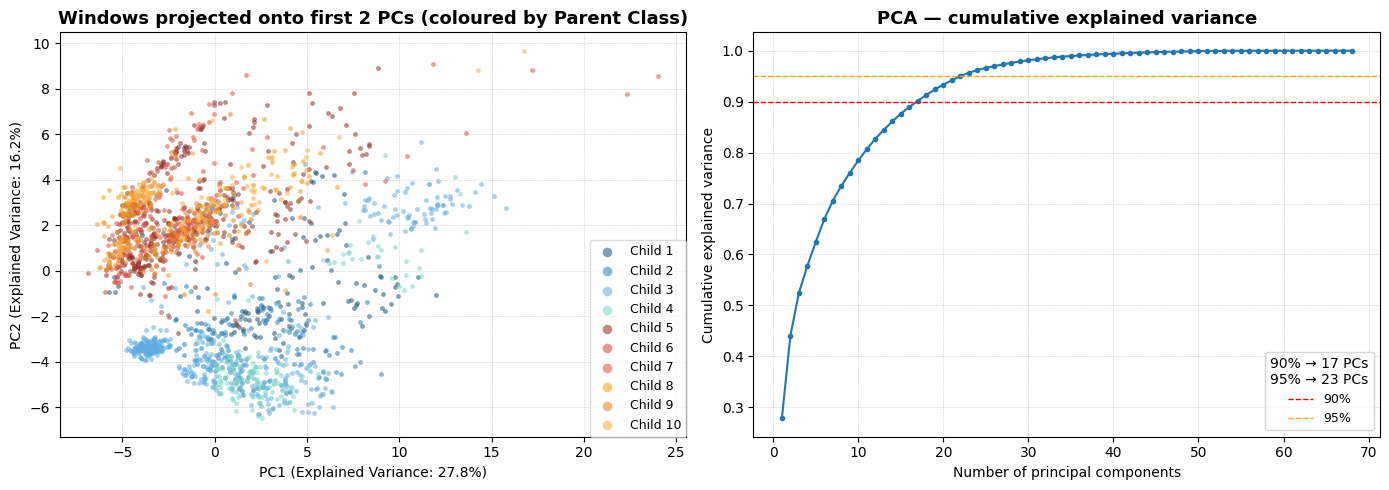

Components needed for 90% variance: 17
Components needed for 95% variance: 23


In [568]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: 2-D scatter coloured by class ---
scatter2d_ex(
    axes[0], X_pca_2d, y_all, palette,
    title=f'Windows projected onto first 2 PCs (coloured by Parent Class)',
    xlabel=f'PC1 (Explained Variance: {pca_2d.explained_variance_ratio_[0]:.1%})',
    ylabel=f'PC2 (Explained Variance: {pca_2d.explained_variance_ratio_[1]:.1%})',
)

# --- Right: cumulative explained variance ---
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].plot(np.arange(1, len(cumvar) + 1), cumvar, marker='.', linewidth=1.5)
axes[1].axhline(0.90, color='red',   linestyle='--', linewidth=1, label='90%')
axes[1].axhline(0.95, color='orange',linestyle='--', linewidth=1, label='95%')
n_90 = int(np.searchsorted(cumvar, 0.90)) + 1
n_95 = int(np.searchsorted(cumvar, 0.95)) + 1
axes[1].set_title('PCA — cumulative explained variance', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of principal components')
axes[1].set_ylabel('Cumulative explained variance')
axes[1].legend(title=f'90% → {n_90} PCs\n95% → {n_95} PCs', fontsize=9)
axes[1].grid(True, linestyle='--', linewidth=0.4, alpha=0.6)

plt.tight_layout()
plt.savefig('pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Components needed for 90% variance: {n_90}")
print(f"Components needed for 95% variance: {n_95}")

In [555]:
# Markers assigned per class; extend the list if more classes are added.
CLASS_MARKERS = ['o', '^', 'D', 'v', 'P', '*', 'X', 'p', 'h']

PARTICIPANT_COLORS = {
    15: '#e6194b',  # red
    16: '#3cb44b',  # green
    17: '#4363d8',  # blue
    18: '#f58231',  # orange
    19: '#911eb4',  # purple
}

def scatter2d_participant_class(
    ax,
    embedding,
    participants,
    classes,
    title='PCA — color=participant, marker=class',
    xlabel='PC1',
    ylabel='PC2',
    alpha=0.65,
    s=40,
    class_names=None,
):
    """
    2-D scatter where:
      - color  encodes participant identity (uses PARTICIPANT_COLORS for known IDs)
      - marker encodes exercise class

    Parameters
    ----------
    ax           : matplotlib Axes
    embedding    : np.ndarray (N, 2)
    participants : np.ndarray (N,) — participant IDs
    classes      : np.ndarray (N,) — class labels
    class_names  : dict {label: str} or None — human-readable class names
    """
    unique_parts   = sorted(np.unique(participants))
    unique_classes = sorted(np.unique(classes))
    print(unique_classes)
    # For participants not in PARTICIPANT_COLORS, assign colours from a cmap
    unlisted = [p for p in unique_parts if p not in PARTICIPANT_COLORS]
    n_extra  = len(unlisted)
    if n_extra > 0:
        cmap = cm.get_cmap('tab20' if n_extra <= 20 else 'hsv', n_extra)
        extra_colors = {p: cmap(i) for i, p in enumerate(unlisted)}
    else:
        extra_colors = {}
    part_colors = {**extra_colors, **PARTICIPANT_COLORS}

    # One marker style per class
    markers = {c: CLASS_MARKERS[i % len(CLASS_MARKERS)]
               for i, c in enumerate(unique_classes)}

    # Plot: iterate over (participant × class) combinations
    for cls in unique_classes:
        for part in unique_parts:
            mask = (participants == part) & (classes == cls)
            if not mask.any():
                continue
            ax.scatter(
                embedding[mask, 0], embedding[mask, 1],
                color=part_colors[part],
                marker=markers[cls],
                alpha=alpha,
                s=s,
                linewidths=0.3,
                edgecolors='white',
            )

    # --- Legend 1: participants (colour) ---
    part_handles = [
        plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=part_colors[p], markersize=7,
                   label=f'P{p}')
        for p in unique_parts
    ]
    leg1 = ax.legend(
        handles=part_handles,
        title='Participant',
        fontsize=7,
        title_fontsize=8,
        loc='upper left',
        bbox_to_anchor=(1.01, 1),
        borderaxespad=0,
        framealpha=0.8,
        ncol=max(1, len(unique_parts) // 10),
    )
    ax.add_artist(leg1)
    class_names = {3: "Arm Curls", 5: "Bench Press"}
    # --- Legend 2: classes (marker shape) ---
    class_handles = [
        plt.Line2D([0], [0], marker=markers[c], color='w',
                   markerfacecolor='dimgray', markersize=9,
                   label=class_names.get(c))
        for c in unique_classes
    ]
    ax.legend(
        handles=class_handles,
        title='Exercise class',
        fontsize=8,
        title_fontsize=8,
        loc='lower left',
        bbox_to_anchor=(1.01, 0),
        borderaxespad=0,
        framealpha=0.8,
    )

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


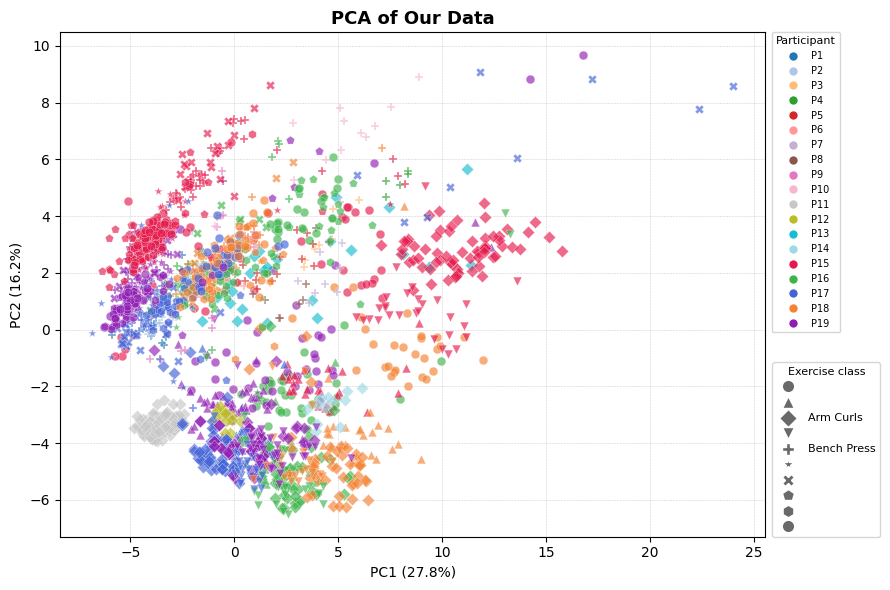

In [556]:
fig, ax = plt.subplots(figsize=(9, 6))
scatter2d_participant_class(
    ax, X_pca_2d, subj_all, y_all,
    title='PCA of Our Data',
    xlabel=f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})',
    ylabel=f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})',
    class_names=CLASS_NAMES_PARENT,
)
plt.tight_layout()
plt.show()

Alternating Dumbell Curl
Alternating Dumbell Curl
Preacher Curls
Preacher Curls
Arm Curls (PARENT)
Arm Curls (PARENT)
Reverse Barbell Curls
Reverse Barbell Curls
Bench Press (PARENT)
Bench Press (PARENT)
Incline Barbell Bench Press
Incline Barbell Bench Press
Decline  Barbell Bench Press
Decline  Barbell Bench Press
Flat Dumbbell Bench Press
Flat Dumbbell Bench Press
Incline Dumbbell Bench Press
Incline Dumbbell Bench Press
Decline  Dumbbell Bench Press
Decline  Dumbbell Bench Press


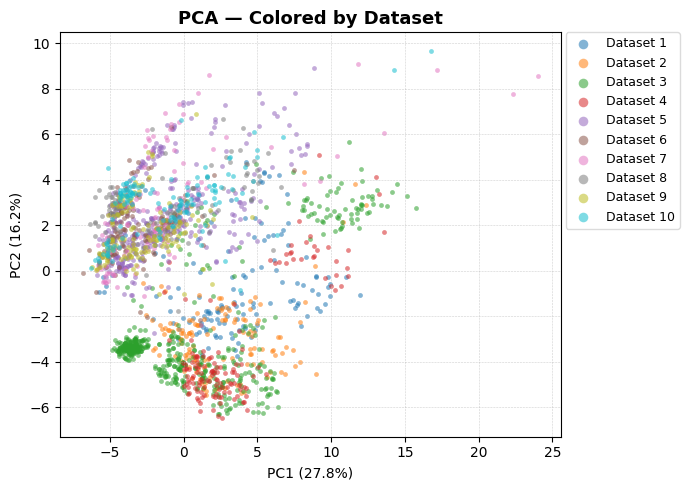

In [557]:
dataset_palette = get_class_palette(sorted(np.unique(datasets_all).tolist()), cmap_name='Set2')
fig, ax = plt.subplots(figsize=(7, 5))
scatter2d_dataset(
    ax, X_pca_2d, y_all, get_class_palette,
    title='PCA — Colored by Dataset',
    xlabel=f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})',
    ylabel=f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})',
)
plt.tight_layout()
plt.savefig('pca_by_subject.png', dpi=150, bbox_inches='tight')
plt.show()

Alternating Dumbell Curl
Alternating Dumbell Curl
Preacher Curls
Preacher Curls
Arm Curls (PARENT)
Arm Curls (PARENT)
Reverse Barbell Curls
Reverse Barbell Curls
Bench Press (PARENT)
Bench Press (PARENT)
Incline Barbell Bench Press
Incline Barbell Bench Press
Decline  Barbell Bench Press
Decline  Barbell Bench Press
Flat Dumbbell Bench Press
Flat Dumbbell Bench Press
Incline Dumbbell Bench Press
Incline Dumbbell Bench Press
Decline  Dumbbell Bench Press
Decline  Dumbbell Bench Press
Class 11
Class 11
Class 12
Class 12
Class 13
Class 13
Class 14
Class 14
Class 15
Class 15
Class 16
Class 16
Class 17
Class 17
Class 18
Class 18
Class 19
Class 19


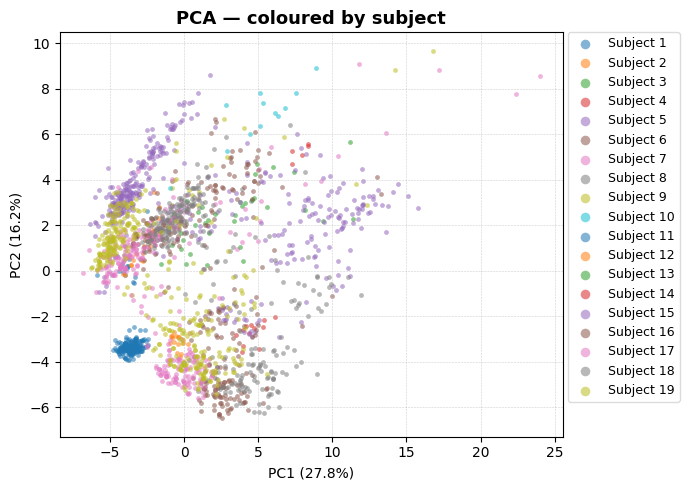

In [558]:
# ---- PCA coloured by subject (to inspect subject-level clustering) ----
subj_palette = get_class_palette(sorted(np.unique(subj_all).tolist()), cmap_name='Set2')
fig, ax = plt.subplots(figsize=(7, 5))
scatter2d_sub(
    ax, X_pca_2d, subj_all, subj_palette,
    title='PCA — coloured by subject',
    xlabel=f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})',
    ylabel=f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})',
)
plt.tight_layout()
plt.savefig('pca_by_subject.png', dpi=150, bbox_inches='tight')
plt.show()

Class l
Class l
Class m
Class m
Class o
Class o


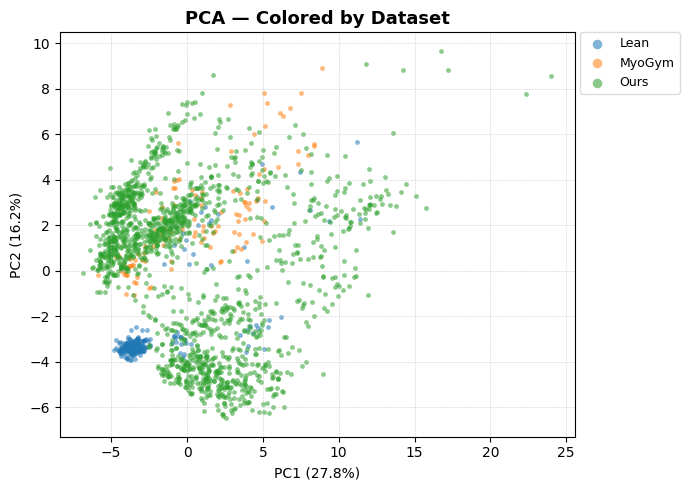

In [559]:
dataset_palette = get_class_palette(sorted(np.unique(datasets_all).tolist()), cmap_name='Set2')
fig, ax = plt.subplots(figsize=(7, 5))
scatter2d_dataset(
    ax, X_pca_2d, datasets_all, dataset_palette,
    title='PCA — Colored by Dataset',
    xlabel=f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})',
    ylabel=f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})',
)
plt.tight_layout()
plt.savefig('pca_by_subject.png', dpi=150, bbox_inches='tight')
plt.show()

## t-SNE

In [560]:
# ---- Pre-reduce with PCA before t-SNE (speeds up & stabilises) ----
N_PCA_FOR_TSNE = min(50, X_scaled.shape[1])
X_pca_50       = PCA(n_components=N_PCA_FOR_TSNE, random_state=42).fit_transform(X_scaled)

tsne    = TSNE(
    n_components=2,
    #perplexity = 15,
    perplexity=min(30, len(X_scaled) - 1),
    learning_rate='auto',
    init='pca',
   
    random_state=42,
    n_jobs=-1,
)
X_tsne = tsne.fit_transform(X_scaled)
print(f"t-SNE embedding shape: {X_tsne.shape}")

t-SNE embedding shape: (1922, 2)


In [561]:
print(np.unique(subj_all))

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


In [562]:
y_all

array([5, 5, 5, ..., 7, 7, 7])

Alternating Dumbell Curl
Preacher Curls
Arm Curls (PARENT)
Reverse Barbell Curls
Bench Press (PARENT)
Incline Barbell Bench Press
Decline  Barbell Bench Press
Flat Dumbbell Bench Press
Incline Dumbbell Bench Press
Decline  Dumbbell Bench Press
Alternating Dumbell Curl
Alternating Dumbell Curl
Preacher Curls
Preacher Curls
Arm Curls (PARENT)
Arm Curls (PARENT)
Reverse Barbell Curls
Reverse Barbell Curls
Bench Press (PARENT)
Bench Press (PARENT)
Incline Barbell Bench Press
Incline Barbell Bench Press
Decline  Barbell Bench Press
Decline  Barbell Bench Press
Flat Dumbbell Bench Press
Flat Dumbbell Bench Press
Incline Dumbbell Bench Press
Incline Dumbbell Bench Press
Decline  Dumbbell Bench Press
Decline  Dumbbell Bench Press
Class 11
Class 11
Class 12
Class 12
Class 13
Class 13
Class 14
Class 14
Class 15
Class 15
Class 16
Class 16
Class 17
Class 17
Class 18
Class 18
Class 19
Class 19


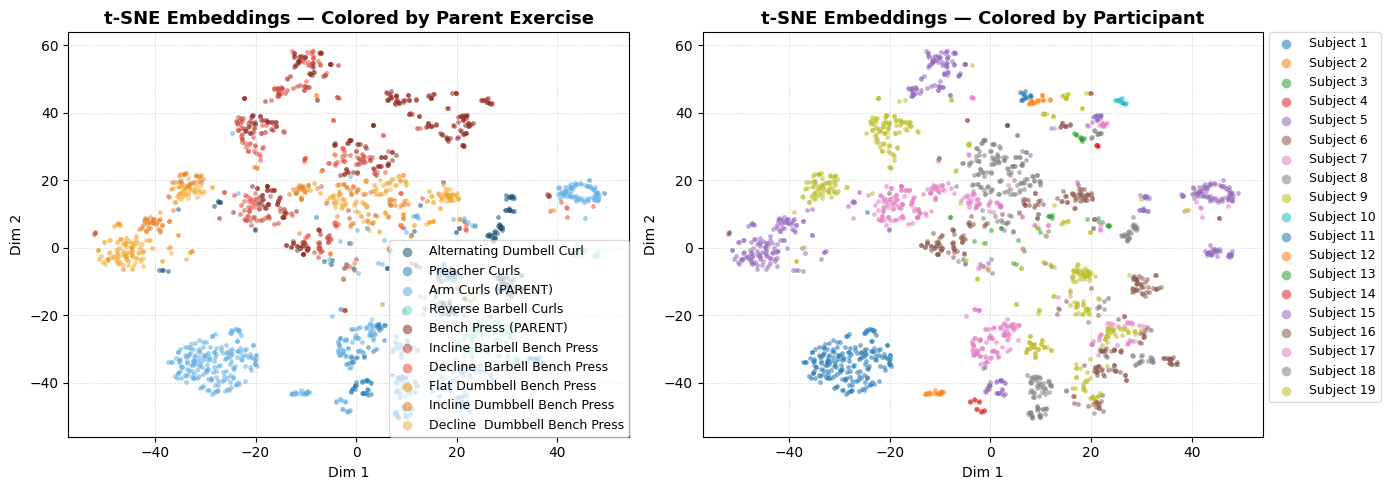

In [563]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter2d_ex(axes[0], X_tsne, y_all,    palette,      title='t-SNE Embeddings — Colored by Parent Exercise')
scatter2d_sub(axes[1], X_tsne, subj_all, subj_palette, title='t-SNE Embeddings — Colored by Participant')


plt.tight_layout()
plt.savefig('tsne_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

Class l
Class l
Class m
Class m
Class o
Class o


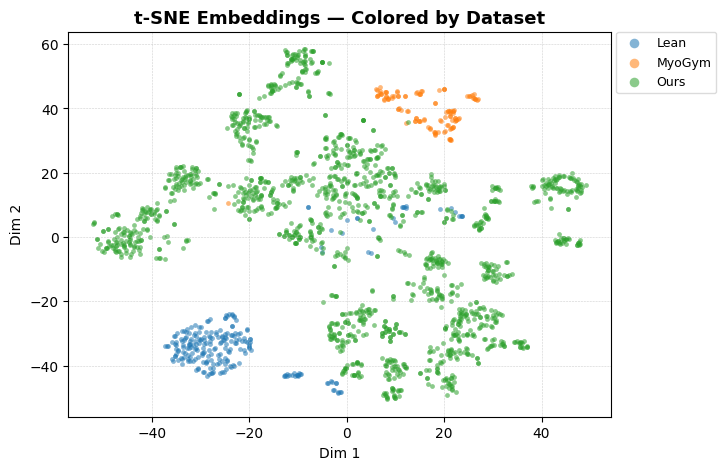

In [564]:
fig, axes = plt.subplots(1, 1, figsize=(7, 5))
scatter2d_dataset(axes, X_tsne, datasets_all, dataset_palette, title='t-SNE Embeddings — Colored by Dataset')

Bench Press (PARENT)
Bench Press (PARENT)
Bench Press (PARENT)
Bench Press (PARENT)
Bench Press (PARENT)
Bench Press (PARENT)
Bench Press (PARENT)
Bench Press (PARENT)
Bench Press (PARENT)
Bench Press (PARENT)
Arm Curls (PARENT)
Arm Curls (PARENT)
Arm Curls (PARENT)
Arm Curls (PARENT)
Alternating Dumbell Curl
Preacher Curls
Arm Curls (PARENT)
Reverse Barbell Curls
Bench Press (PARENT)
Incline Barbell Bench Press
Decline  Barbell Bench Press
Flat Dumbbell Bench Press
Incline Dumbbell Bench Press
Decline  Dumbbell Bench Press
Alternating Dumbell Curl
Preacher Curls
Arm Curls (PARENT)
Reverse Barbell Curls
Bench Press (PARENT)
Incline Barbell Bench Press
Decline  Barbell Bench Press
Flat Dumbbell Bench Press
Incline Dumbbell Bench Press
Decline  Dumbbell Bench Press
Preacher Curls
Arm Curls (PARENT)
Reverse Barbell Curls
Bench Press (PARENT)
Incline Barbell Bench Press
Decline  Barbell Bench Press
Flat Dumbbell Bench Press
Incline Dumbbell Bench Press
Decline  Dumbbell Bench Press
Alterna

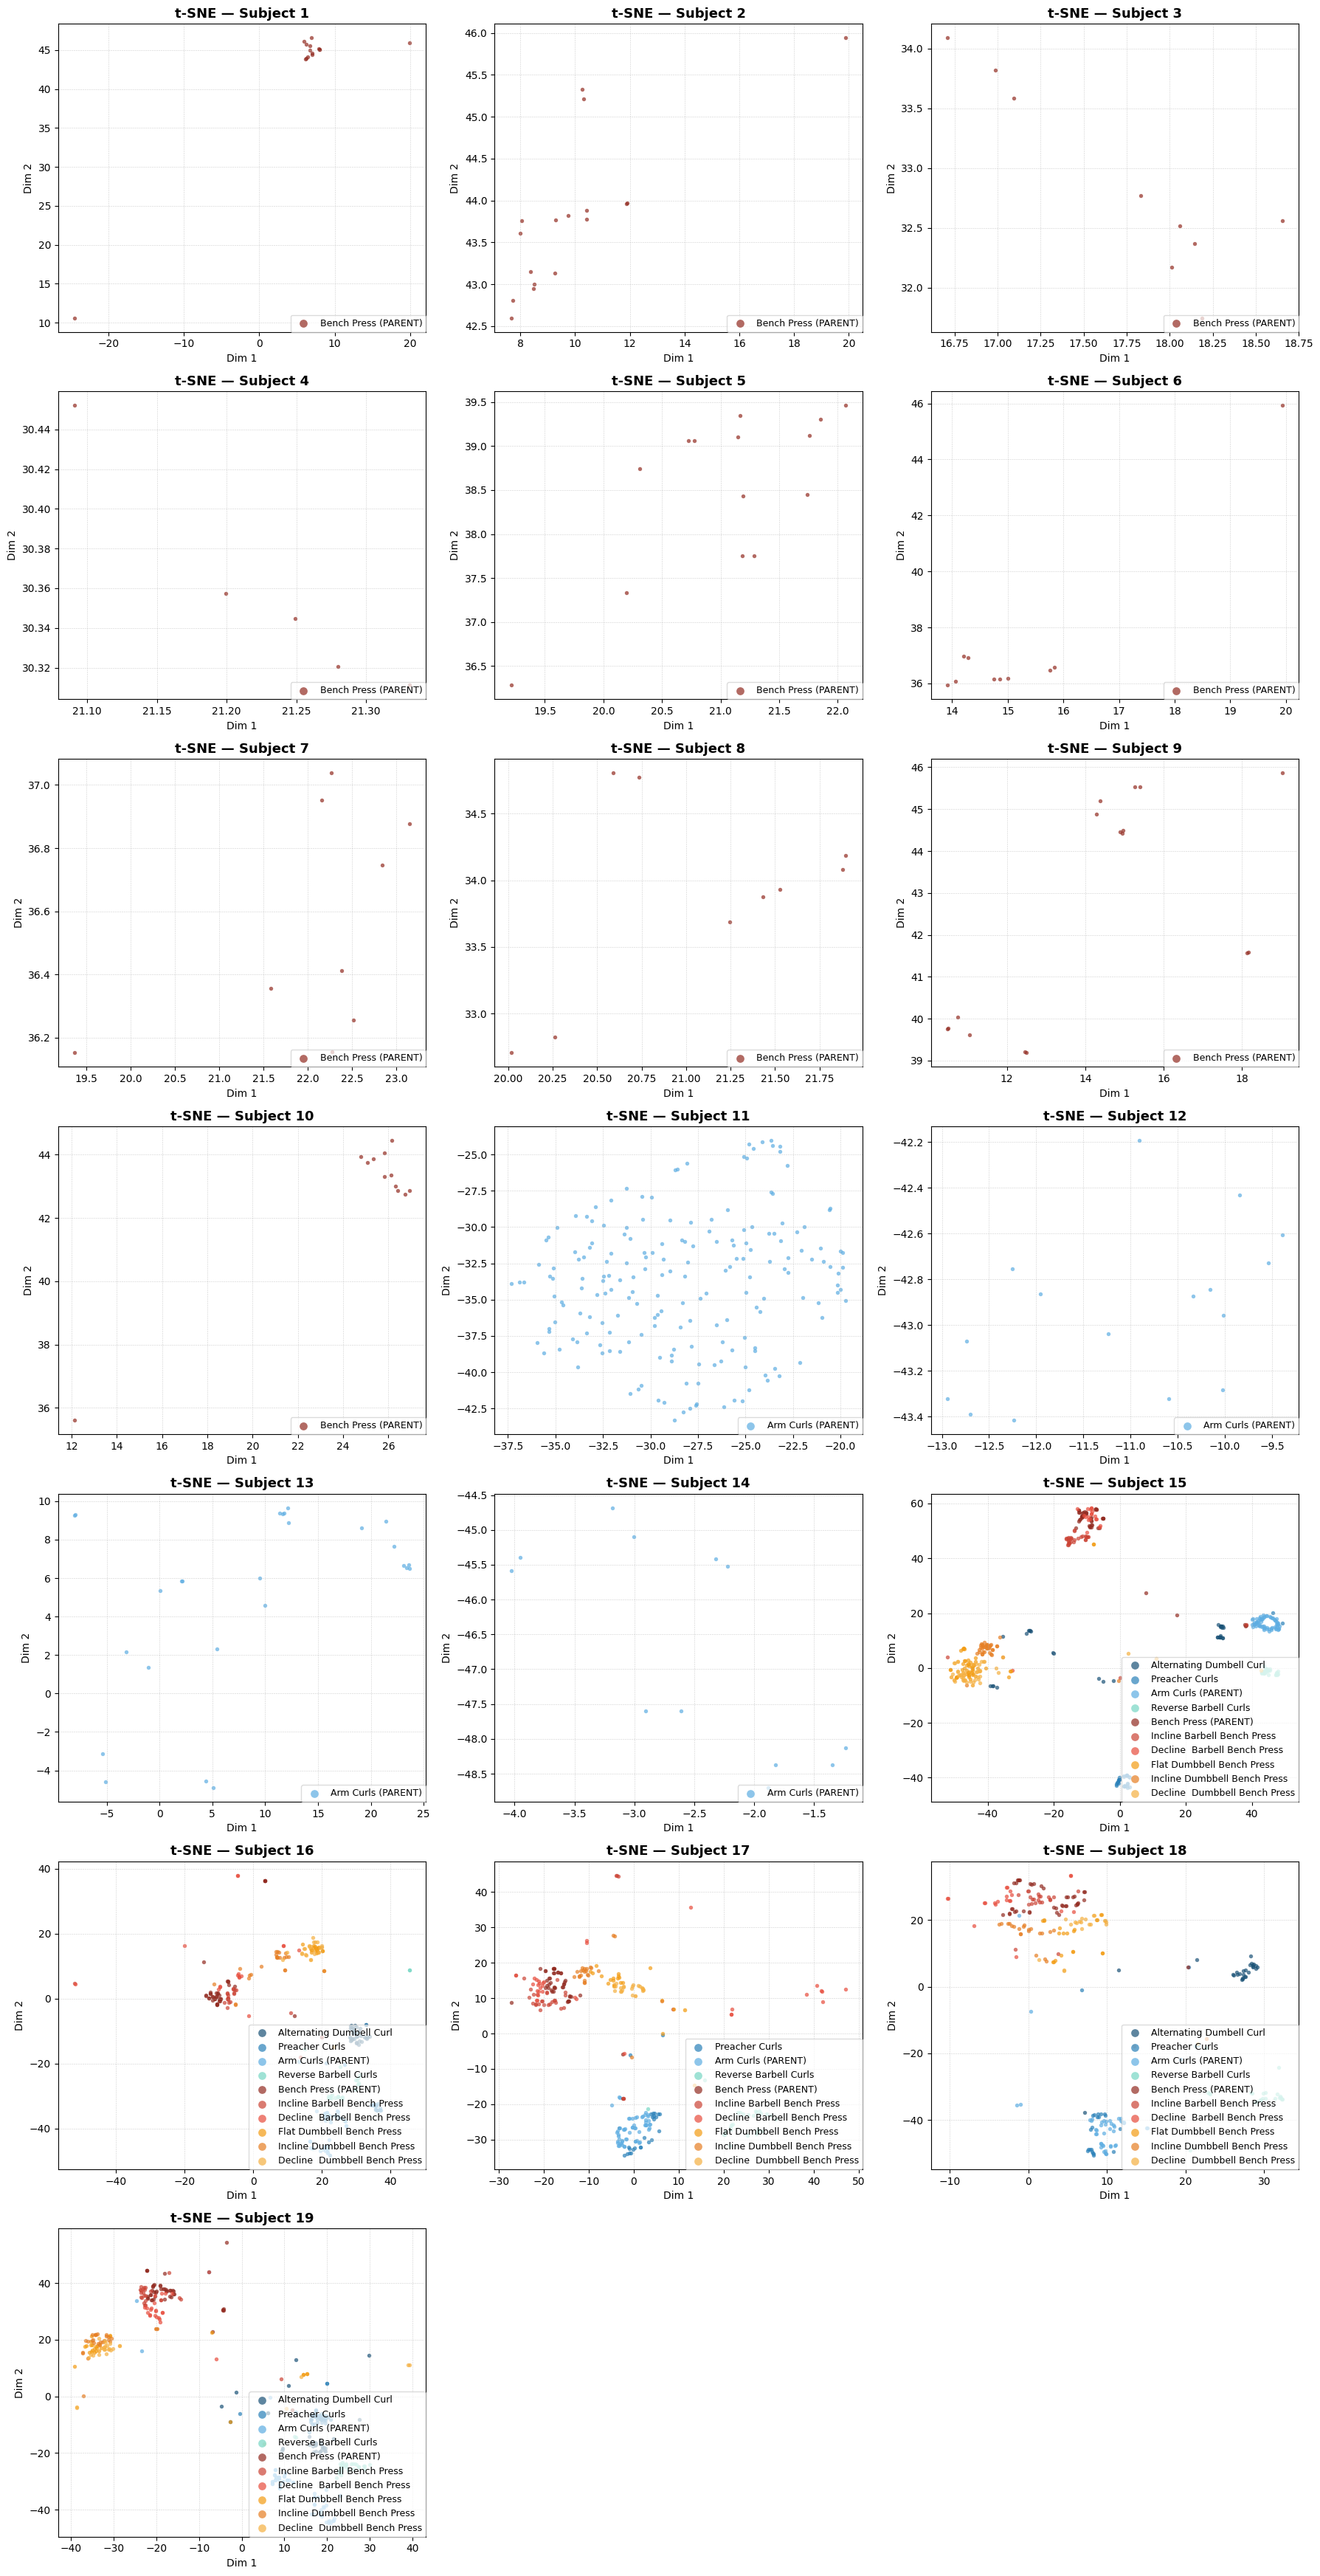

In [565]:
n_subj = len(subjects)
ncols  = min(3, n_subj)
nrows  = int(np.ceil(n_subj / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), squeeze=False)

for idx, subj in enumerate(subjects):
    ax   = axes[idx // ncols][idx % ncols]
    mask = subj_all == subj
    scatter2d_ex(
        ax, X_tsne[mask], y_all[mask], palette,
        title=f't-SNE — Subject {subj}',
        s=15, alpha=0.7,
    )

# Hide any unused subplots
for idx in range(n_subj, nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

plt.tight_layout()
plt.savefig('tsne_per_subject.png', dpi=150, bbox_inches='tight')
plt.show()

## UMAP

In [566]:
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=25,
    min_dist=0.1,
    metric='euclidean',
    random_state=42,
    spread = 0.15
)
X_umap = reducer.fit_transform(X_scaled)
print(f"UMAP embedding shape: {X_umap.shape}")

NameError: name 'umap' is not defined

Arm Curl
Bench Press
Class 21
Class 21
Class 22
Class 22
Class 23
Class 23
Class 24
Class 24
Class 25
Class 25


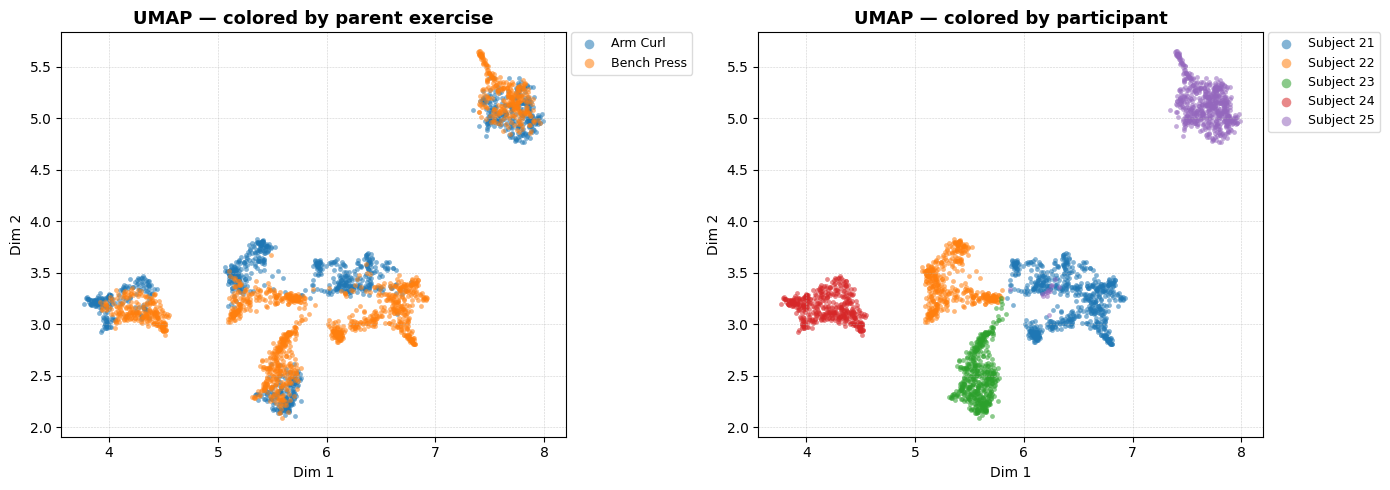

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter2d_ex(axes[0], X_umap, y_all,    palette,      title='UMAP — colored by parent exercise')
scatter2d_sub(axes[1], X_umap, subj_all, subj_palette, title='UMAP — colored by participant')

plt.tight_layout()
plt.savefig('umap_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

## Side-by-side comparison: PCA · t-SNE · UMAP

Arm Curl
Arm Curl
Arm Curl
Bench Press
Bench Press
Bench Press
Arm Curl
Arm Curl
Arm Curl
Bench Press
Bench Press
Bench Press
Arm Curl
Arm Curl
Arm Curl
Bench Press
Bench Press
Bench Press


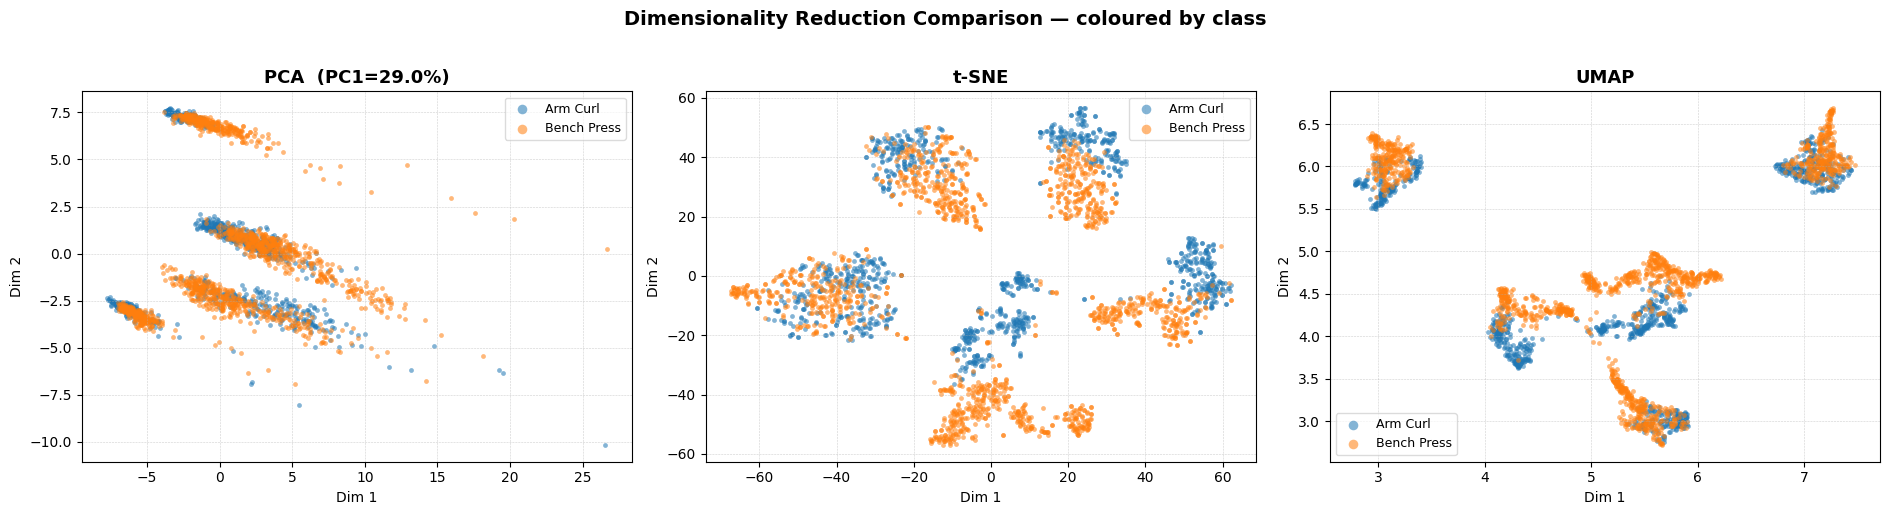

In [ ]:
embeddings = [
    (X_pca_2d, f'PCA  (PC1={pca_2d.explained_variance_ratio_[0]:.1%})'),
    (X_tsne,   't-SNE'),
    (X_umap,   'UMAP'),
]

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for ax, (emb, title) in zip(axes, embeddings):
    scatter2d(ax, emb, y_all, palette, title=title)

fig.suptitle('Dimensionality Reduction Comparison — coloured by class',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('dim_reduction_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Per-subject UMAP (small multiples)

Arm Curl
Arm Curl
Arm Curl
Bench Press
Bench Press
Bench Press
Arm Curl
Arm Curl
Arm Curl
Bench Press
Bench Press
Bench Press
Arm Curl
Arm Curl
Arm Curl
Bench Press
Bench Press
Bench Press
Arm Curl
Arm Curl
Arm Curl
Bench Press
Bench Press
Bench Press
Arm Curl
Arm Curl
Arm Curl
Bench Press
Bench Press
Bench Press


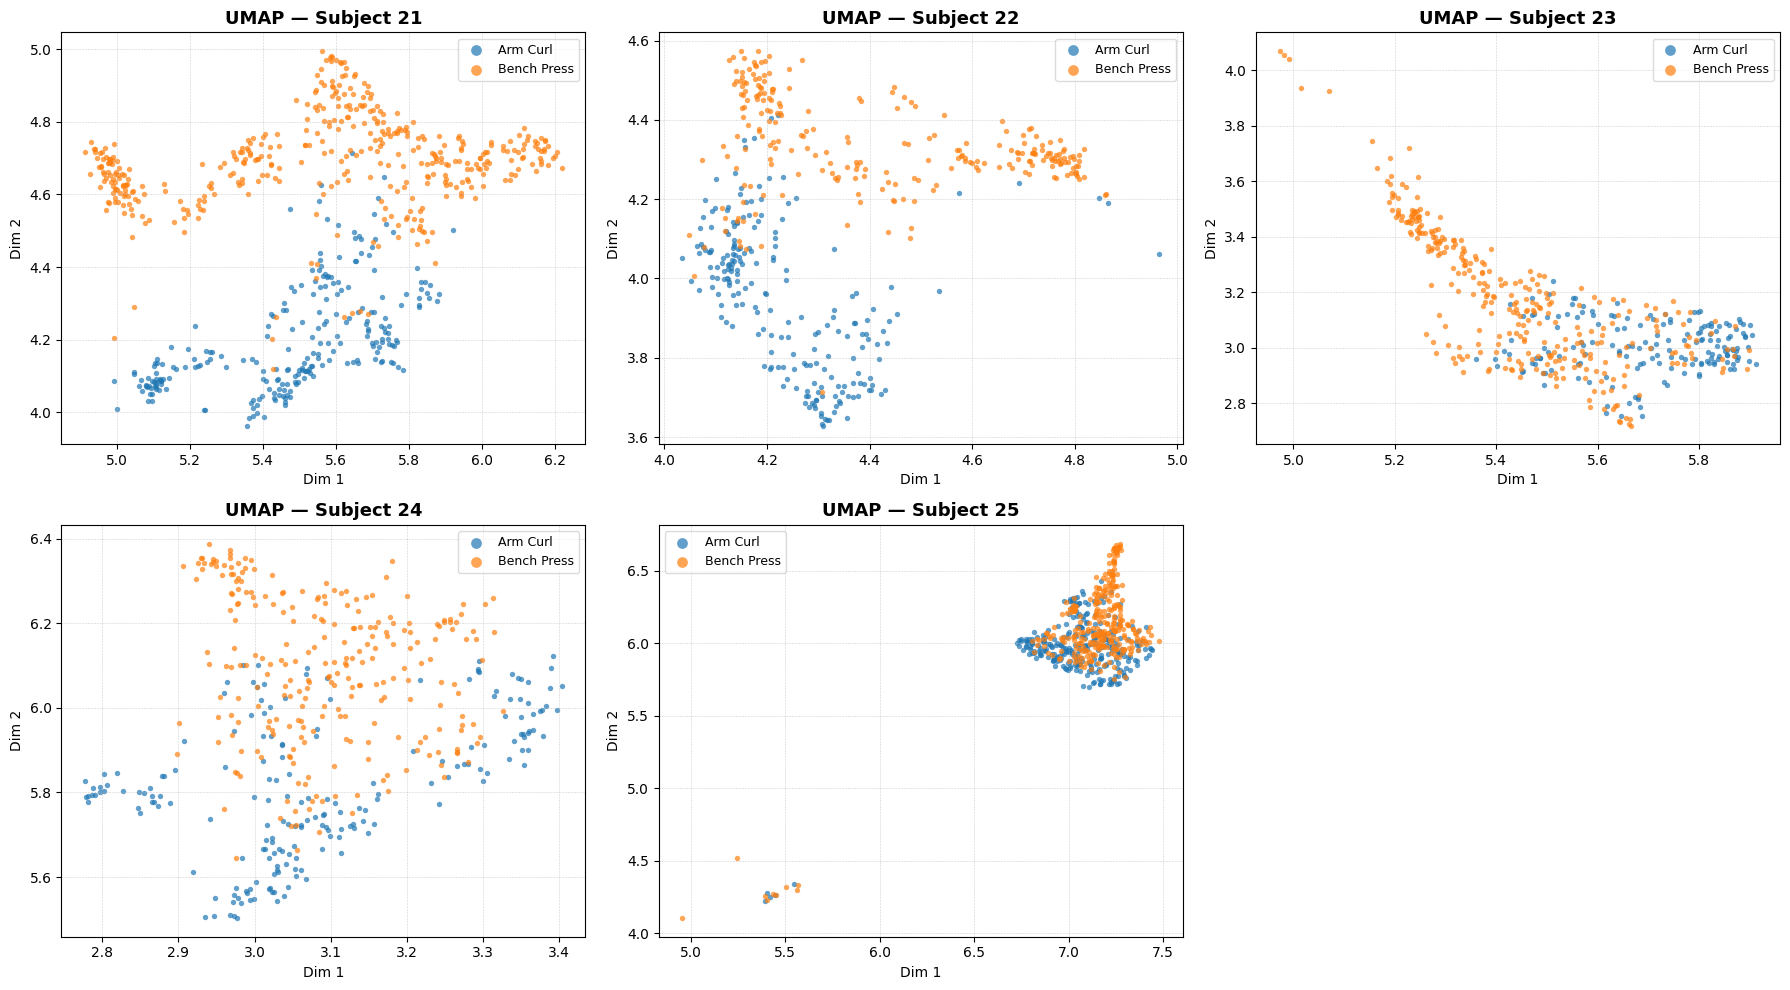

In [ ]:
n_subj = len(subjects)
ncols  = min(3, n_subj)
nrows  = int(np.ceil(n_subj / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), squeeze=False)

for idx, subj in enumerate(subjects):
    ax   = axes[idx // ncols][idx % ncols]
    mask = subj_all == subj
    scatter2d(
        ax, X_umap[mask], y_all[mask], palette,
        title=f'UMAP — Subject {subj}',
        s=15, alpha=0.7,
    )

# Hide any unused subplots
for idx in range(n_subj, nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

plt.tight_layout()
plt.savefig('umap_per_subject.png', dpi=150, bbox_inches='tight')
plt.show()

## Class distribution (sanity check)

Arm Curl
Bench Press


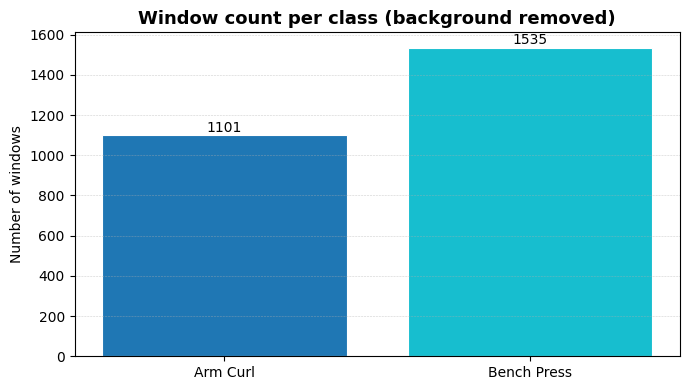

Window counts: {1: 1101, 2: 1535}


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
counts  = {c: int(np.sum(y_all == c)) for c in unique_classes}
bars    = ax.bar(
    [class_label(c) for c in unique_classes],
    [counts[c] for c in unique_classes],
    color=[palette[c] for c in unique_classes],
    edgecolor='white', linewidth=0.8,
)
for bar, c in zip(bars, unique_classes):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 2, str(counts[c]),
            ha='center', va='bottom', fontsize=10)
ax.set_title('Window count per class (background removed)', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of windows')
ax.grid(axis='y', linestyle='--', linewidth=0.4, alpha=0.6)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Window counts:", counts)